<a href="https://colab.research.google.com/github/enviouseli/Implementation_skin_cancer_detection/blob/main/Implementation_skin_cancer_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Skin Cancer Detection using HAM10000 Dataset

This notebook will guide you through the process of building a visual pipeline for skin cancer detection using the HAM10000 dataset, as requested. The pipeline involves `ConvNeXtV2` for local feature extraction, a `ViT-B/16` encoder for global spatial relationships, and a `Mamba State Space block` for feature reinforcement, followed by a `softmax` classification head.

In [1]:
import kagglehub
import os
from google.colab import userdata

# Load the HF_TOKEN from Colab's secrets and set it as an environment variable
try:
    hf_token = userdata.get('HF_TOKEN')
    os.environ['HF_TOKEN'] = hf_token
    print("HF_TOKEN loaded from Colab secrets and set as environment variable.")
except userdata.SecretNotFoundError:
    print("HF_TOKEN secret not found. Please ensure it's set in Colab secrets.")
except Exception as e:
    print(f"An error occurred while setting HF_TOKEN: {e}")

# This will download the dataset files to your Colab environment
dataset_path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", dataset_path)
print("""Please note: You might need to adjust 'metadata_path' and 'image_dir' variables
       in the following cells based on the downloaded directory structure.""")

HF_TOKEN loaded from Colab secrets and set as environment variable.
Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000
Please note: You might need to adjust 'metadata_path' and 'image_dir' variables
       in the following cells based on the downloaded directory structure.


In [ ]:
# List the contents of the downloaded Kaggle dataset directory recursively
# This will help us find the exact location of the zip files and the metadata CSV.
!ls {dataset_path}

ham10000_images_part_1	HAM10000_images_part_2	hmnist_28_28_RGB.csv
HAM10000_images_part_1	HAM10000_metadata.csv	hmnist_8_8_L.csv
ham10000_images_part_2	hmnist_28_28_L.csv	hmnist_8_8_RGB.csv


In [ ]:
# List the contents of the 'ham10000_images_part_1' directory
!ls -alR {dataset_path}/ham10000_images_part_1

In [ ]:
!echo {dataset_path}

/kaggle/input/skin-cancer-mnist-ham10000


In [ ]:
!cat {dataset_path}/HAM10000_metadata.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


metadata_path = os.path.join(dataset_path, 'HAM10000_metadata.csv')

# Function to find the correct image path by checking both part_1 and part_2 directories
def find_image_full_path(image_id, base_dataset_path):
    # Check in 'ham10000_images_part_1'
    path_part1 = os.path.join(base_dataset_path, 'ham10000_images_part_1', image_id + '.jpg')
    if os.path.exists(path_part1):
        return path_part1
    # Check in 'HAM10000_images_part_2'
    path_part2 = os.path.join(base_dataset_path, 'HAM10000_images_part_2', image_id + '.jpg')
    if os.path.exists(path_part2):
        return path_part2
    return None # Return None if image is not found in either part

# Load the metadata
try:
    df = pd.read_csv(metadata_path)
    print("Metadata loaded successfully.")
    display(df.head())
    print("\nDataset Information:")
    df.info()

    # Create a column for the full image path using the helper function
    df['image_path'] = df['image_id'].apply(lambda x: find_image_full_path(x, dataset_path))

    # Check for images that were not found
    missing_images_count = df['image_path'].isnull().sum()
    if missing_images_count > 0:
        print(f"Warning: {missing_images_count} images listed in metadata were not found.")
    else:
        print("All images from metadata successfully located.")

except FileNotFoundError:
    print(f"Error: Metadata file not found at {metadata_path}. Please check the path.")
    print("Please ensure 'HAM10000_metadata.csv' is in the correct directory.")
    df = None


Metadata loaded successfully.


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB
All images from metadata successfully located.


### Consolidating Image Directories

To simplify image access, we'll move all images from `ham10000_images_part_1` and `HAM10000_images_part_2` into a single directory called `ham10000_images`. After moving, we will update the `image_path` column in the DataFrame.

In [3]:
import shutil

# Define the new consolidated image directory in a writable location
# The /kaggle/input/ directory is read-only, so we'll create the new directory in /kaggle/working/
consolidated_image_dir = os.path.join('/kaggle/working/', 'ham10000_images')
os.makedirs(consolidated_image_dir, exist_ok=True)

print(f"Created consolidated image directory: {consolidated_image_dir}")

# Source directories are still within the read-only dataset_path
part1_dir = os.path.join(dataset_path, 'ham10000_images_part_1')
part2_dir = os.path.join(dataset_path, 'HAM10000_images_part_2')

def move_images(source_dir, destination_dir):
    if os.path.exists(source_dir):
        print(f"Copying images from {source_dir} to {destination_dir}...")
        for filename in os.listdir(source_dir):
            if filename.endswith('.jpg'):
                source_path = os.path.join(source_dir, filename)
                destination_path = os.path.join(destination_dir, filename)
                # Use shutil.copy2 instead of shutil.move because source is read-only.
                shutil.copy2(source_path, destination_path)
        print(f"Finished copying images from {source_dir}.")
    else:
        print(f"Source directory not found: {source_dir}")

move_images(part1_dir, consolidated_image_dir)
move_images(part2_dir, consolidated_image_dir)

print("All images consolidated.")


Created consolidated image directory: /kaggle/working/ham10000_images
Copying images from /kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_1 to /kaggle/working/ham10000_images...
Finished copying images from /kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_1.
Copying images from /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2 to /kaggle/working/ham10000_images...
Finished copying images from /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2.
All images consolidated.


In [4]:
# Update the DataFrame's image_path column
# Now all images are in the 'consolidated_image_dir'
df['image_path'] = df['image_id'].apply(lambda x: os.path.join(consolidated_image_dir, x + '.jpg'))

# Verify some image paths after consolidation
print("\nSample image paths after consolidation:")
display(df['image_path'].sample(5))

# Re-check for missing images
missing_images_count_after_consolidation = df['image_path'].apply(lambda x: not os.path.exists(x)).sum()
if missing_images_count_after_consolidation > 0:
    print(f"Warning: {missing_images_count_after_consolidation} images listed in metadata were not found after consolidation.")
else:
    print("All images successfully located in the consolidated directory.")


Sample image paths after consolidation:


,image_path
672,/kaggle/working/ham10000_images/ISIC_0031951.jpg
7146,/kaggle/working/ham10000_images/ISIC_0032555.jpg
3886,/kaggle/working/ham10000_images/ISIC_0032188.jpg
5998,/kaggle/working/ham10000_images/ISIC_0031441.jpg
6755,/kaggle/working/ham10000_images/ISIC_0027249.jpg


All images successfully located in the consolidated directory.


In [5]:
# Check if the DataFrame was loaded successfully before proceeding
if df is not None:
    # Display basic statistics
    print("\nDescriptive Statistics:")
    display(df.describe(include='all'))

    # Check for missing values
    print("\nMissing values per column:")
    display(df.isnull().sum())

    # Handle missing 'age' values by filling with the median
    if df['age'].isnull().any():
        df['age'].fillna(df['age'].median(), inplace=True)
        print("Missing 'age' values filled with median.")

    # Handle missing 'lesion_id' by filling with 'unknown'
    if df['lesion_id'].isnull().any():
        df['lesion_id'].fillna('unknown', inplace=True)
        print("Missing 'lesion_id' values filled with 'unknown'.")

    print("\nMissing values after handling:")
    display(df.isnull().sum())


Descriptive Statistics:


,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path
count,10015,10015,10015,10015,9958.000000,10015,10015,10015
unique,7470,10015,7,4,NaN,3,15,10015
top,HAM_0003789,ISIC_0032258,nv,histo,NaN,male,back,/kaggle/working/ham10000_images/ISIC_0032258.jpg
freq,6,1,6705,5340,NaN,5406,2192,1
mean,NaN,NaN,NaN,NaN,51.863828,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,16.968614,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,40.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,50.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,65.000000,NaN,NaN,NaN



Missing values per column:


,0
lesion_id,0
image_id,0
dx,0
dx_type,0
age,57
sex,0
localization,0
image_path,0


Missing 'age' values filled with median.

Missing values after handling:


/tmp/ipykernel_1490/1663668741.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)


,0
lesion_id,0
image_id,0
dx,0
dx_type,0
age,0
sex,0
localization,0
image_path,0


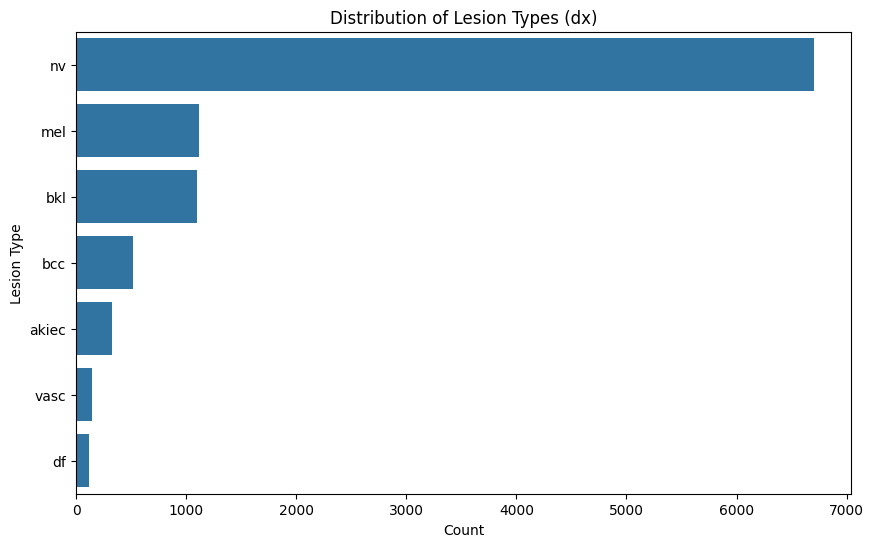


Encoded lesion types:


,dx,dx_encoded
9687,akiec,0
2462,bcc,1
0,bkl,2
1095,df,3
1211,mel,4
64,nv,5
2320,vasc,6



Sample image paths:


,image_path
66,/kaggle/working/ham10000_images/ISIC_0026104.jpg
8654,/kaggle/working/ham10000_images/ISIC_0026293.jpg
9185,/kaggle/working/ham10000_images/ISIC_0026580.jpg
8945,/kaggle/working/ham10000_images/ISIC_0024441.jpg
6866,/kaggle/working/ham10000_images/ISIC_0028401.jpg


Found image: /kaggle/working/ham10000_images/ISIC_0027419.jpg
Found image: /kaggle/working/ham10000_images/ISIC_0025030.jpg
Found image: /kaggle/working/ham10000_images/ISIC_0026769.jpg
Found image: /kaggle/working/ham10000_images/ISIC_0025661.jpg
Found image: /kaggle/working/ham10000_images/ISIC_0031633.jpg

Found 10015 out of 10015 images based on metadata paths.


In [6]:
# Visualize the distribution of target classes (dx)
if df is not None:
    plt.figure(figsize=(10, 6))
    sns.countplot(y='dx', data=df, order=df['dx'].value_counts().index)
    plt.title('Distribution of Lesion Types (dx)')
    plt.xlabel('Count')
    plt.ylabel('Lesion Type')
    plt.show()

    # Encode categorical labels to numerical
    le = LabelEncoder()
    df['dx_encoded'] = le.fit_transform(df['dx'])
    print("\nEncoded lesion types:")
    display(df[['dx', 'dx_encoded']].drop_duplicates().sort_values('dx_encoded'))

    # Create a column for the full image path
    #df['image_path'] = df['image_id'].apply(lambda x: os.path.join(image_dir, x + '.jpg'))

    # Verify some image paths
    print("\nSample image paths:")
    display(df['image_path'].sample(5))

    # Check if image files exist for a sample
    sample_image_paths = df['image_path'].head(5)
    for path in sample_image_paths:
        if not os.path.exists(path):
            print(f"Warning: Image file not found at {path}. Please verify the `image_dir` variable.")
        else:
            print(f"Found image: {path}")

    # Add a check for the total number of images found versus metadata entries
    found_images_count = sum(os.path.exists(path) for path in df['image_path'])
    print(f"\nFound {found_images_count} out of {len(df)} images based on metadata paths.")
    if found_images_count < len(df):
        print("Note: Some images listed in metadata might be missing from the specified image directory.")

### 2. Data Preparation for Model Training

To train our deep learning model, we need to prepare the image data. This involves:
1.  **Splitting the dataset**: Dividing the dataset into training and validation sets.
2.  **Image Transformations**: Applying augmentations and normalizations to the images.
3.  **Custom Dataset Class**: Creating a PyTorch `Dataset` to handle image loading and transformations.
4.  **Data Loaders**: Creating PyTorch `DataLoader`s for efficient batching during training.

In [7]:
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# Split the data into training and validation sets
# We will use 'image_path' and 'dx_encoded' for training
if df is not None:
    train_df, val_df = train_test_split(
        df, test_size=0.2, random_state=42, stratify=df['dx_encoded']
    )

    print(f"Training set size: {len(train_df)}")
    print(f"Validation set size: {len(val_df)}")
else:
    print("DataFrame 'df' is not available. Cannot split data.")
    train_df, val_df = None, None

Training set size: 8012
Validation set size: 2003


In [8]:
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        image = Image.open(img_path).convert('RGB')
        label = self.dataframe.iloc[idx]['dx_encoded']

        if self.transform:
            image = self.transform(image)
        return image, label

# Define image transformations
# These transformations are common for image classification tasks
# and can be adjusted based on the specific model requirements.
# For ConvNeXtV2 and ViT, typically images are resized to 224x224 or 384x384.
image_size = 224 # Common size for many vision models

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(image_size), # Randomly crop and resize
    transforms.RandomHorizontalFlip(),       # Randomly flip horizontally
    transforms.RandomVerticalFlip(),         # Randomly flip vertically
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1), # Random color jitter
    transforms.ToTensor(),                   # Convert image to PyTorch Tensor
    transforms.Normalize(mean=[0.763, 0.546, 0.571], std=[0.089, 0.119, 0.124]) # Normalize with HAM10000 dataset mean/std
])

val_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)), # Resize to a fixed size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.763, 0.546, 0.571], std=[0.089, 0.119, 0.124])
])

# Create dataset instances
if train_df is not None and val_df is not None:
    train_dataset = HAM10000Dataset(train_df, transform=train_transforms)
    val_dataset = HAM10000Dataset(val_df, transform=val_transforms)

    print(f"Train dataset created with {len(train_dataset)} samples.")
    print(f"Validation dataset created with {len(val_dataset)} samples.")
else:
    print("Cannot create datasets: training or validation DataFrame is missing.")
    train_dataset, val_dataset = None, None

Train dataset created with 8012 samples.
Validation dataset created with 2003 samples.


In [9]:
# Create data loaders
batch_size = 32

if train_dataset is not None and val_dataset is not None:
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    print(f"Train DataLoader created with {len(train_loader)} batches.")
    print(f"Validation DataLoader created with {len(val_loader)} batches.")
else:
    print("Cannot create DataLoaders: training or validation dataset is missing.")
    train_loader, val_loader = None, None

Train DataLoader created with 251 batches.
Validation DataLoader created with 63 batches.


### 3. Model Definition: ConvNeXtV2 + ViT-Mamba Hybrid

Now, we'll define the architecture for our skin cancer detection model. The visual pathway consists of three sequential processing stages:

1.  **ConvNeXtV2-Tiny**: Extracts fine-grained local features (edge sharpness, surface texture, color gradients within small regions of the image).
2.  **ViT-B/16 Encoder**: Processes the entire image as a set of 196 patches, capturing broader spatial relationships.
3.  **Mamba State Space Block**: Reads through the patch sequence output by ViT, selectively reinforcing relevant features and suppressing noise.

Finally, a **softmax classification head** will produce a probability distribution across the seven lesion classes.

In [10]:
import torch.nn as nn
import timm # PyTorch Image Models library for ConvNeXtV2 and ViT

# Define the number of output classes based on the dataset
num_classes = len(df['dx_encoded'].unique()) if df is not None else 7 # Default to 7 if df is not loaded
print(f"Number of classes for classification: {num_classes}")

Number of classes for classification: 7


In [11]:
class MambaBlock(nn.Module):
    def __init__(self, d_model, d_state=16, d_conv=3, expand=2): # Changed d_conv to 3
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.proj_in = nn.Linear(d_model, d_model * expand * 2)
        # For d_conv=3, padding=3//2=1 will preserve sequence length
        self.conv = nn.Conv1d(d_model * expand, d_model * expand, kernel_size=d_conv, groups=d_model * expand,
                              padding=d_conv // 2) # Corrected padding
        self.act = nn.SiLU()
        self.proj_out = nn.Linear(d_model * expand, d_model)
        self.d_state = d_state # For simplicity, not fully implementing SSM dynamics

    def forward(self, x):
        # x: (batch_size, sequence_length, d_model)
        shortcut = x
        x = self.norm(x)
        x_in = self.proj_in(x)
        x_proj, x_gate = x_in.chunk(2, dim=-1) # Split into projected and gate features

        # Permute for Conv1d: (batch_size, d_model_expanded, sequence_length)
        x_proj_conv = x_proj.permute(0, 2, 1)
        x_conv_out = self.conv(x_proj_conv).permute(0, 2, 1) # Permute back

        x = self.act(x_conv_out) * self.act(x_gate) # Gated activation
        x = self.proj_out(x)

        return x + shortcut # Residual connection

In [12]:
class ConvNeXtV2_ViT_Mamba_Hybrid(nn.Module):
    def __init__(self, num_classes=7, convnext_model_name='convnextv2_tiny', vit_model_name='vit_base_patch16_224_in21k'):
        super().__init__()

        self.convnext = timm.create_model(convnext_model_name, pretrained=True, num_classes=0, global_pool='avg')
        # The output feature dimension of ConvNeXtV2-Tiny (after global average pooling) is 768.
        convnext_output_dim = self.convnext.num_features
        self.vit = timm.create_model(vit_model_name, pretrained=True, num_classes=0)
        # The output of ViT's encoder (before pooling/head) is a sequence of tokens/patches.
        # The dimension of each token is vit.embed_dim (768 for ViT-B/16).
        # The number of patches (sequence length) is typically 196 + 1 for CLS token.
        vit_embed_dim = self.vit.embed_dim

        # Adjust ViT's head to be an identity layer if it has one by default (timm might add one)
        if hasattr(self.vit, 'head'):
            self.vit.head = nn.Identity()
        if hasattr(self.vit, 'fc_norm'): # Some ViTs have a final normalization before head
            self.vit.fc_norm = nn.Identity()

        self.mamba_block = MambaBlock(d_model=vit_embed_dim)

        self.classifier = nn.Sequential(
            nn.LayerNorm(vit_embed_dim), # Normalize the CLS token feature
            nn.Linear(vit_embed_dim, num_classes) # Final linear layer for classification
        )

    def forward(self, x):
        # x is the input image (batch_size, 3, image_size, image_size)

        # Let's try combining the features from ConvNeXtV2 with the ViT's sequence.
        # ConvNeXtV2-Tiny output after global average pooling: (batch_size, 768)
        convnext_features = self.convnext(x) # (batch_size, 768)
        vit_features_sequence = self.vit.forward_features(x)

        cls_token_vit = vit_features_sequence[:, 0, :]
        patch_tokens_vit = vit_features_sequence[:, 1:, :]

        # Simple combination: add ConvNeXtV2 features to ViT's CLS token
        # Or, a learnable projection if dimensions were different.
        fused_cls_token = cls_token_vit + convnext_features # Element-wise addition
        fused_cls_token = fused_cls_token.unsqueeze(1) # Add sequence dimension back

        # Reconstruct the sequence with the fused CLS token
        fused_vit_sequence = torch.cat((fused_cls_token, patch_tokens_vit), dim=1)

        # Mamba Block: Reads through the patch sequence output by ViT (now fused)
        mamba_output_sequence = self.mamba_block(fused_vit_sequence)

        # Classification: Use the CLS token from the Mamba output sequence
        # The CLS token (first element of the sequence) is typically used for classification.
        cls_token_final = mamba_output_sequence[:, 0, :]
        logits = self.classifier(cls_token_final)

        return logits

### Running the Hybrid Model on Sample Images

Now, let's create an instance of our `ConvNeXtV2_ViT_Mamba_Hybrid` model and run the first 10 images from our validation set through it to see the output. This helps verify that the model's forward pass is working as expected.

In [13]:
import os

print(f"The HF_TOKEN environment variable is: {os.getenv('HF_TOKEN')}")

The HF_TOKEN environment variable is: KGAT_32d473d499d949dd8b3e996ded3784f4


In [14]:
# Instantiate the model
model = ConvNeXtV2_ViT_Mamba_Hybrid(num_classes=num_classes)

# Move model to CPU or GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Set the model to evaluation mode
model.eval()

# Get the first 10 images from the validation dataset
# We'll create a temporary DataLoader for this
sample_val_df = val_df.head(10)
sample_dataset = HAM10000Dataset(sample_val_df, transform=val_transforms)
sample_loader = DataLoader(sample_dataset, batch_size=10, shuffle=False)

# Get one batch of images and labels
for images, labels in sample_loader:
    images = images.to(device)
    print(f"Input images batch shape: {images.shape}")

    # Perform a forward pass
    with torch.no_grad(): # Disable gradient calculations for inference
        output_logits = model(images)

    print(f"Output logits shape: {output_logits.shape}")
    print("\nSample output logits (first 5 images):\n", output_logits[:5])
    break # We only need the first batch

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name vit_base_patch16_224_in21k to current vit_base_patch16_224.augreg_in21k.
  model = create_fn(


model.safetensors:   0%|          | 0.00/410M [00:00<?, ?B/s]

Input images batch shape: torch.Size([10, 3, 224, 224])
Output logits shape: torch.Size([10, 7])

Sample output logits (first 5 images):
 tensor([[ 1.0715, -0.0494,  0.0936, -0.6556,  0.7752, -0.4656, -0.3112],
        [ 0.0900, -0.5112,  0.4127, -0.4528,  0.8126, -1.0267, -0.0864],
        [ 1.0085, -0.0647,  0.9116, -1.2960,  1.5690, -0.6738, -0.2765],
        [ 0.5789, -0.4448,  0.8366, -0.7868,  1.4611, -0.7713, -0.5037],
        [ 0.1139, -0.4700,  0.5939, -1.1499,  1.3351, -0.8939, -0.7879]],
       device='cuda:0')


### 4. Model Training

In [15]:
import torch.optim as optim
from tqdm.notebook import tqdm

# Define training parameters
num_epochs = 10  # You can adjust this based on your computational resources and convergence
num_epochs = 7  # Changing it to 7 since it started overfitting after this iteration
num_epochs = 10  # running again with 10

learning_rate = 1e-4

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

# Learning Rate Scheduler (optional, but often helpful)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

print(f"Training model on device: {device}")
print(f"Number of epochs: {num_epochs}")
print(f"Learning rate: {learning_rate}")

Training model on device: cuda
Number of epochs: 10
Learning rate: 0.0001


In [16]:
# Training loop
best_val_accuracy = 0.0
# Path to save the best model
model_save_path = 'best_hybrid_model.pth'

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Training phase
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Train)")
    for images, labels in train_loop:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # Zero the gradients
        outputs = model(images) # Forward pass
        loss = criterion(outputs, labels) # Calculate loss
        loss.backward() # Backward pass
        optimizer.step() # Update weights

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

        train_loop.set_postfix(loss=loss.item())

    epoch_train_loss = running_loss / total_samples
    epoch_train_accuracy = correct_predictions / total_samples

    # Validation phase
    model.eval() # Set model to evaluation mode
    val_running_loss = 0.0
    val_correct_predictions = 0
    val_total_samples = 0

    with torch.no_grad(): # Disable gradient calculation for validation
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Validation)")
        for images, labels in val_loop:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total_samples += labels.size(0)
            val_correct_predictions += (predicted == labels).sum().item()

            val_loop.set_postfix(loss=loss.item())

    epoch_val_loss = val_running_loss / val_total_samples
    epoch_val_accuracy = val_correct_predictions / val_total_samples

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Train Loss: {epoch_train_loss:.4f}, Train Accuracy: {epoch_train_accuracy:.4f} - "
          f"Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {epoch_val_accuracy:.4f}")

    # Update learning rate scheduler
    scheduler.step(epoch_val_loss)

    # Save the best model
    if epoch_val_accuracy > best_val_accuracy:
        best_val_accuracy = epoch_val_accuracy
        torch.save(model.state_dict(), model_save_path)
        print(f"Saved best model with validation accuracy: {best_val_accuracy:.4f}")

print("Training complete.")

Epoch 1/10 (Train):   0%|          | 0/251 [00:00<?, ?it/s]

Epoch 1/10 (Validation):   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1/10 - Train Loss: 0.7685, Train Accuracy: 0.7292 - Val Loss: 0.5393, Val Accuracy: 0.8173
Saved best model with validation accuracy: 0.8173


Epoch 2/10 (Train):   0%|          | 0/251 [00:00<?, ?it/s]

Epoch 2/10 (Validation):   0%|          | 0/63 [00:00<?, ?it/s]

...

Epoch 9/10 (Validation):   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 9/10 - Train Loss: 0.2344, Train Accuracy: 0.9154 - Val Loss: 0.4305, Val Accuracy: 0.8527


Epoch 10/10 (Train):   0%|          | 0/251 [00:00<?, ?it/s]

Epoch 10/10 (Validation):   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 10/10 - Train Loss: 0.2262, Train Accuracy: 0.9172 - Val Loss: 0.3331, Val Accuracy: 0.8947
Saved best model with validation accuracy: 0.8947
Training complete.


### 5. Validate Results with a Random Image

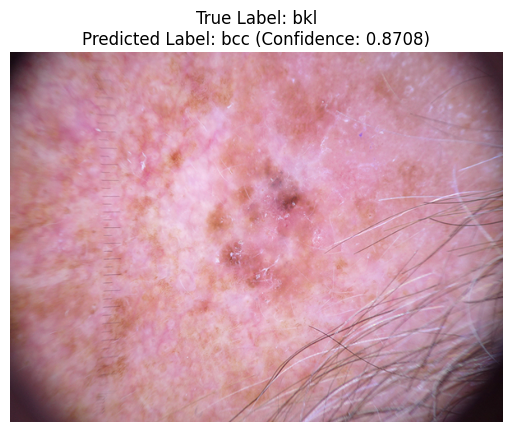

Image ID: ISIC_0025661
True diagnosis: bkl
Predicted diagnosis: bcc with confidence 0.8708


In [46]:
import random
from PIL import Image
import matplotlib.pyplot as plt

# Load the best model
model.load_state_dict(torch.load(model_save_path))
model.eval() # Set to evaluation mode

# Get a random image from the validation set
random_idx = random.randint(0, len(val_df) - 1)
random_image_path = val_df.iloc[random_idx]['image_path']
true_label_encoded = val_df.iloc[random_idx]['dx_encoded']
true_label_name = le.inverse_transform([true_label_encoded])[0]

# Load and transform the image
image = Image.open(random_image_path).convert('RGB')
# Use validation transforms for inference
input_image = val_transforms(image).unsqueeze(0) # Add batch dimension
input_image = input_image.to(device)

# Make prediction
with torch.no_grad():
    output = model(input_image)
    probabilities = torch.softmax(output, dim=1)
    predicted_prob, predicted_class_encoded = torch.max(probabilities, 1)

predicted_label_name = le.inverse_transform([predicted_class_encoded.item()])[0]

# Display the image and prediction
plt.imshow(image)
plt.title(f"True Label: {true_label_name}\nPredicted Label: {predicted_label_name} (Confidence: {predicted_prob.item():.4f})")
plt.axis('off')
plt.show()

print(f"Image ID: {val_df.iloc[random_idx]['image_id']}")
print(f"True diagnosis: {true_label_name}")
print(f"Predicted diagnosis: {predicted_label_name} with confidence {predicted_prob.item():.4f}")